In [141]:
import nbformat
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from datetime import datetime, timedelta
import pandas as pd


In [142]:

# 設定你的 notebook 檔案路徑
CMUnotebook_path = '../../Code/MS_project/CMU model.ipynb'
PSS_modelnotebook_path = '../../Code/MS_project/PSS_model.ipynb'
per2_path = 'PSS_model_Per-emb-2.ipynb'
per50_path = 'PSS_model_Per-emb-50.ipynb'
per2t_path = 'PSS_per-emb-2_turtorial.ipynb'
findroot2_path = 'Find_root-2.ipynb'
findroot50_path = 'Find_root-50.ipynb'
corrdinate_path = 'corrdinate.ipynb'

# pss_py_path = '../../Code/MS_project/pss.py'

# 讀取 notebook
with open(CMUnotebook_path, 'r', encoding='utf-8') as f:
    cmunb = nbformat.read(f, as_version=4)
with open(PSS_modelnotebook_path, 'r', encoding='utf-8') as f:
    psnb = nbformat.read(f, as_version=4)
with open(per2_path, 'r', encoding='utf-8') as f:
    ps2nb = nbformat.read(f, as_version=4)
with open(per50_path, 'r', encoding='utf-8') as f:
    ps50nb = nbformat.read(f, as_version=4)
with open(per2t_path, 'r', encoding='utf-8') as f:
    ps2tnb = nbformat.read(f, as_version=4)
with open(findroot2_path, 'r', encoding='utf-8') as f:
    psf2nb = nbformat.read(f, as_version=4)
with open(findroot50_path, 'r', encoding='utf-8') as f:
    psf50nb = nbformat.read(f, as_version=4)
with open(corrdinate_path, 'r', encoding='utf-8') as f:
    pscnb = nbformat.read(f, as_version=4)

# 統計 cell 數
CMU_total_cells = len(cmunb.cells)
pss_total_cells = len(psnb.cells)
per2_total_cells = len(ps2nb.cells)
per50_total_cells = len(ps50nb.cells)
per2t_total_cells = len(ps2tnb.cells)
findroot2_total_cells = len(psf2nb.cells)
findroot50_total_cells = len(psf50nb.cells)
corrdinate_total_cells = len(pscnb.cells)

# # 顯示結果
# print(f"Total number of cells: {CMU_total_cells}")

# cell_types = Counter(cell.cell_type for cell in cmunb.cells)
# print(cell_types)


In [143]:
per2_total_cells

194

In [144]:
plt.rcParams['font.family'] = 'Heiti TC'  # macOS 例子（其他系統見下方）


# 1. 定義起始與結束時間
start_date = datetime(2024, 2, 22)   # 2024年3月第一週（週一）
end_date = datetime(2025, 5, 18)    # 前天

# 2. 每週為一個單位
week_dates = pd.date_range(start=start_date, end=end_date, freq='W-MON')  # 每週一當作一週開始
weeks = np.arange(1, len(week_dates) + 1)

# 3. 建立週數標籤：'2024-10' 這種形式
week_labels = [f"{date.isocalendar().year}-{date.isocalendar().week:02d}" for date in week_dates]

In [145]:
# 想查詢的目標日，例如 2024 年 4 月 2 日
target_date = datetime(2025, 5, 12)

# 計算週數（整除 7）
delta_days = (target_date - start_date).days
workload_index = delta_days // 7 + 1  # 加 1 表示從第1週開始

print(f"{target_date.date()} 是第 {workload_index} 個 workload（第 {workload_index} 週）")


2025-05-12 是第 64 個 workload（第 64 週）


In [156]:
weekload = np.zeros_like(weeks)
weekload[1] = 3
for i in range(1,5):
    rad = np.random.random_sample()
    weekload[i+1] = CMU_total_cells * (i+rad) / (4+rad)
for i in range(1,17):
    rad = np.random.random_sample()
    weekload[i+4] = 30 + pss_total_cells * (i+rad) / (16+rad)
for i in range(1, 41):
    rad = np.random.random_sample()
    weekload[i+19] = 174 + per2_total_cells * (i+rad) / (40+rad)
weekload[60] = weekload[59] + per50_total_cells / 2
weekload[61] = weekload[60] + per50_total_cells * 2
weekload[62] = weekload[61] + (per2t_total_cells + findroot2_total_cells) * 20
weekload[63] = weekload[62] + (findroot50_total_cells + corrdinate_total_cells) * 20


In [167]:
raw_growth = np.diff(weekload) / weekload[:-1] * 100
growth = np.concatenate(([0, 0], raw_growth))[:len(weekload)]
growth = np.nan_to_num(growth, nan=0, posinf=20, neginf=20)
growth


/var/folders/9m/kvnj0x452kx_fptbkd6sbbxm0000gn/T/ipykernel_59515/3628956146.py:1: RuntimeWarning: divide by zero encountered in divide
  raw_growth = np.diff(weekload) / weekload[:-1] * 100


array([  0.        ,   0.        ,  20.        , 266.66666667,
        54.54545455,  29.41176471,  95.45454545,  23.25581395,
        16.98113208,   9.67741935,  11.76470588,  17.10526316,
         6.74157303,   9.47368421,   7.69230769,   8.92857143,
         7.37704918,   6.10687023,   5.75539568,   6.12244898,
         5.76923077,  10.3030303 ,   2.1978022 ,   2.68817204,
         1.57068063,   2.57731959,   3.51758794,   1.45631068,
         1.9138756 ,   1.87793427,   3.68663594,   1.77777778,
         2.18340611,   1.70940171,   1.68067227,   2.0661157 ,
         2.0242915 ,   2.77777778,   1.54440154,   1.14068441,
         2.2556391 ,   1.83823529,   1.80505415,   1.41843972,
         2.0979021 ,   1.02739726,   2.03389831,   1.66112957,
         1.30718954,   1.61290323,   1.58730159,   1.25      ,
         1.54320988,   1.51975684,   1.49700599,   1.47492625,
         1.1627907 ,   1.43678161,   1.41643059,   1.39664804,
         1.37741047,  24.45652174,  78.60262009,  61.12

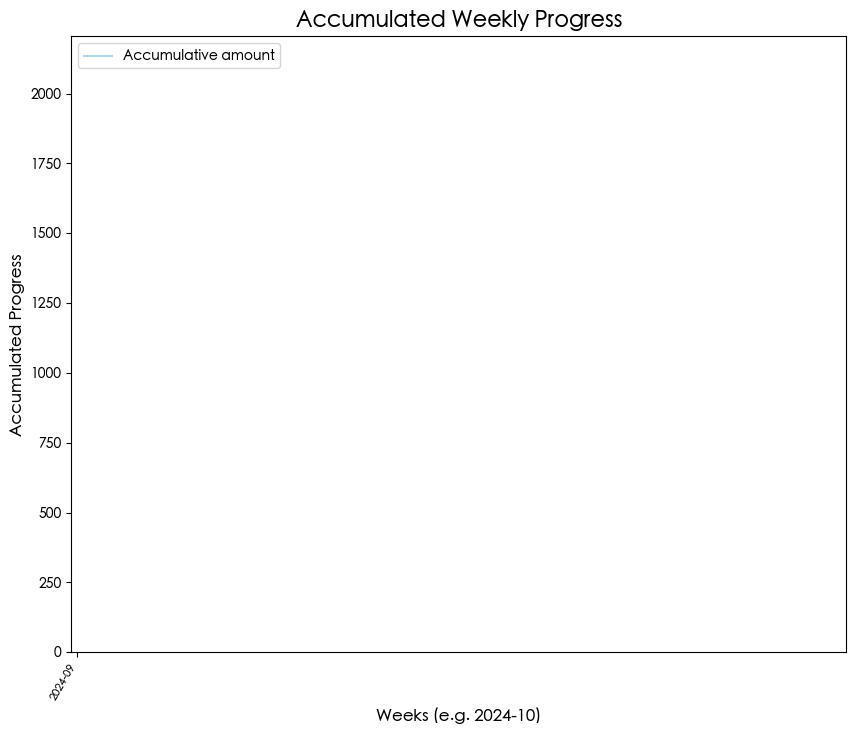

In [173]:
fig, ax1 = plt.subplots(figsize=(10, 8))
# ax2 = ax1.twinx()

def update(frame):
    ax1.clear()
    # ax2.clear()

    x = weeks[:frame+1]
    y = weekload[:frame+1]
    g = growth[:frame+1]

    # ax1.bar(x, y, color='skyblue', label='工作量')
    ax1.plot(x, y, color='lightblue', label='Accumulative amount')

    # ax2.plot(x, g, color='C3', label='週增率')

    ax1.set_xlim(0.5, weeks[-1] + 0.5)  # 固定為20週
    ax1.set_ylim(0, weekload[-1] * 1.2)

    # y2_min = min(0, g.min() - 10)
    # y2_max = max(0, g.max() + 10)
    # ax2.set_ylim(y2_min, y2_max)

    # === 調整 y 軸標籤 ===

    ax1.set_ylabel("Accumulated Progress", fontsize=12)    # ax2.set_ylabel("週增率 (%)", fontsize=12, rotation=270, labelpad=20)
    # ax2.yaxis.set_label_position('right')
    # ax2.yaxis.tick_right()
    ax1.set_xlabel("Weeks (e.g. 2024-10)", fontsize=12)
    ax1.set_xticks(weeks[:frame+1])
    ax1.set_xticklabels(week_labels[:frame+1], rotation=60, ha='right', fontsize=8)
    
    ax1.set_title("Accumulated Weekly Progress", fontsize=16)

    ax1.legend(loc='upper left')
    # ax2.legend(loc='upper right')

    # === milestone ===
    # milestones = {5: "模擬完成", 10: "第一階段結果", 15: "投稿準備"}
    # for milestone in [5, 10, 15]:
    #     if milestone <= weeks[frame]:
    #         ax1.axvline(x=milestone, color='gray', linestyle='--', linewidth=1)
    #         ax1.text(milestone, ax1.get_ylim()[1]*0.95, '★', color='gray',
    #                 fontsize=16, ha='center', va='top')


ani = animation.FuncAnimation(fig, update, frames=len(weeks), interval=600)

# 儲存
ani.save("progress_dynamic.gif", writer='pillow', dpi=150, fps=4)
